In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("CO2_Emissions.csv")
df.head()
df.isnull().sum()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [4]:
print("--- SHAPE (Rows, Cols) ---")
print(df.shape)


--- SHAPE (Rows, Cols) ---
(7385, 12)


In [5]:
display(df.head())


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [7]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [8]:
df.columns.to_list()

['Make',
 'Model',
 'Vehicle Class',
 'Engine Size(L)',
 'Cylinders',
 'Transmission',
 'Fuel Type',
 'Fuel Consumption City (L/100 km)',
 'Fuel Consumption Hwy (L/100 km)',
 'Fuel Consumption Comb (L/100 km)',
 'Fuel Consumption Comb (mpg)',
 'CO2 Emissions(g/km)']

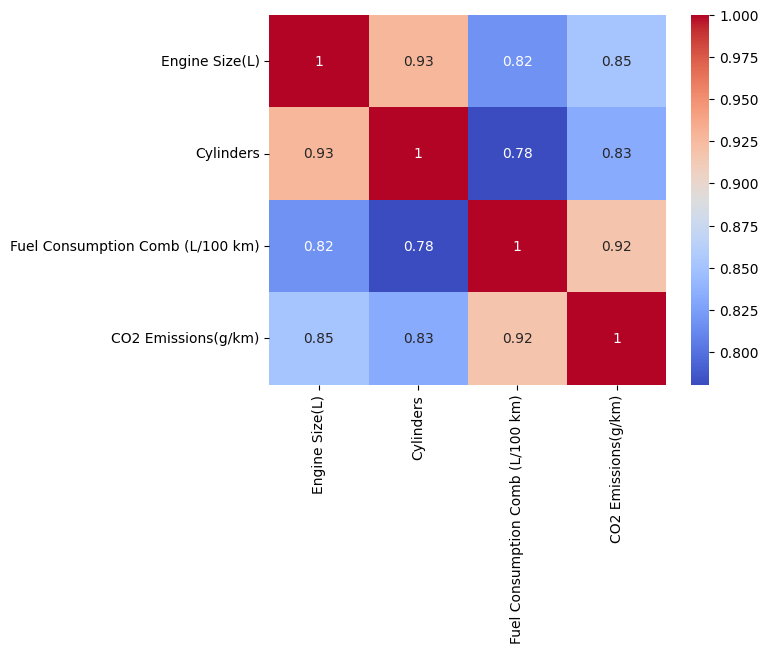

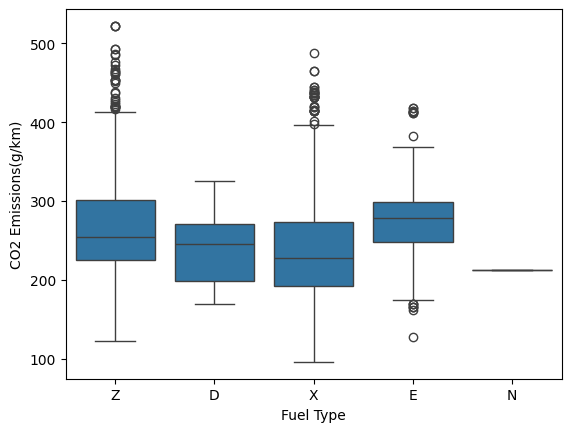

In [49]:
# 1. Select only the number columns
numerical_cols = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)', 'CO2 Emissions(g/km)']

# 2. Calculate the Correlation Score (-1 to +1)
corr_matrix = df[numerical_cols].corr()

# 3. Draw the Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

# 4. Draw the Boxplot (for Categories)
sns.boxplot(x='Fuel Type', y='CO2 Emissions(g/km)', data=df)
plt.show()


Text(0, 0.5, 'CO2 Emissions (g/km)')

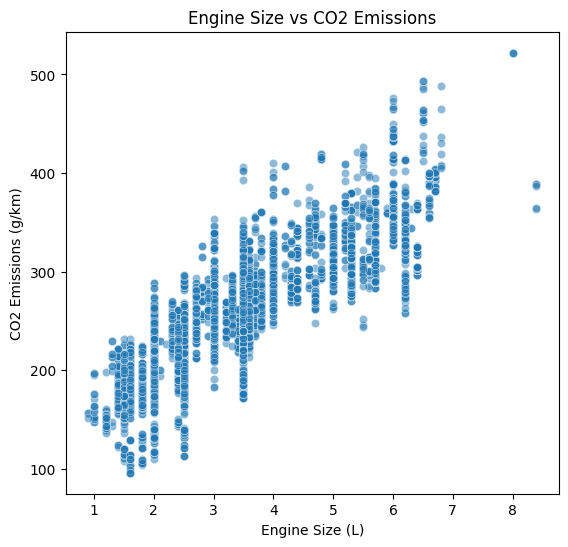

In [12]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x='Engine Size(L)', y='CO2 Emissions(g/km)', data=df , alpha=0.5)
plt.title("Engine Size vs CO2 Emissions")
plt.xlabel("Engine Size (L)")
plt.ylabel("CO2 Emissions (g/km)")


Text(0, 0.5, 'CO2 Emissions (g/km)')

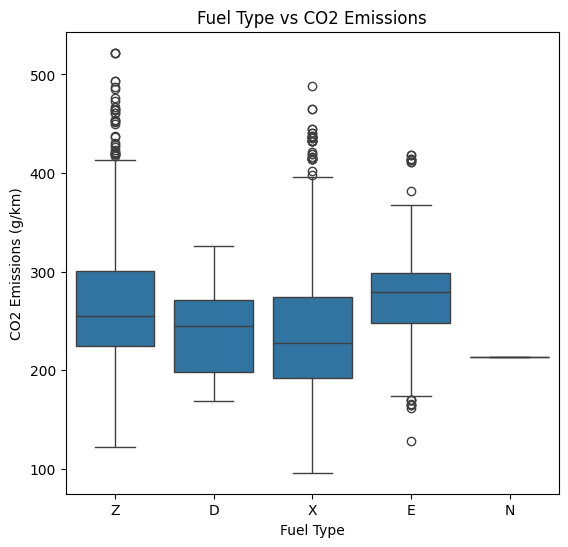

In [15]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x="Fuel Type", y="CO2 Emissions(g/km)")
plt.title("Fuel Type vs CO2 Emissions")
plt.xlabel("Fuel Type")
plt.ylabel("CO2 Emissions (g/km)")

In [20]:
features = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)', 'Fuel Type'] 
target = 'CO2 Emissions(g/km)'
X = df[features]
y = df[target]

X = pd.get_dummies(X, drop_first=True)
X.head()


,Engine Size(L),Cylinders,Fuel Consumption Comb (L/100 km),Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z
0,2.0,4,8.5,False,False,False,True
1,2.4,4,9.6,False,False,False,True
2,1.5,4,5.9,False,False,False,True
3,3.5,6,11.1,False,False,False,True
4,3.5,6,10.6,False,False,False,True


In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Original Columns:", df[features].columns.tolist())
print("\nNew 'Translated' Columns:", X_train.columns.tolist())
print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Original Columns: ['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)', 'Fuel Type']

New 'Translated' Columns: ['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)', 'Fuel Type_E', 'Fuel Type_N', 'Fuel Type_X', 'Fuel Type_Z']

Training Data Shape: (5908, 7)
Testing Data Shape: (1477, 7)


In [29]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)



LinearRegression()

In [30]:
print(f"\nIntercept (Bias): {model.intercept_:.2f}")



Intercept (Bias): 36.39


In [31]:
for feature, coef in zip(X_train.columns, model.coef_):
    print(f"{feature}: {coef:.2f}")

Engine Size(L): 0.25
Cylinders: 0.64
Fuel Consumption Comb (L/100 km): 22.33
Fuel Type_E: -143.64
Fuel Type_N: -0.00
Fuel Type_X: -30.37
Fuel Type_Z: -30.21


In [43]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(X_test)
y_pred[:5]


r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse
print(f"R2 Score (Accuracy): {r2:.4f}")
print(f"RMSE (Average Error): {rmse:.2f} g/km")



R2 Score (Accuracy): 0.9883
RMSE (Average Error): 6.34 g/km


/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/nithinys/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


<Axes: xlabel='CO2 Emissions(g/km)'>

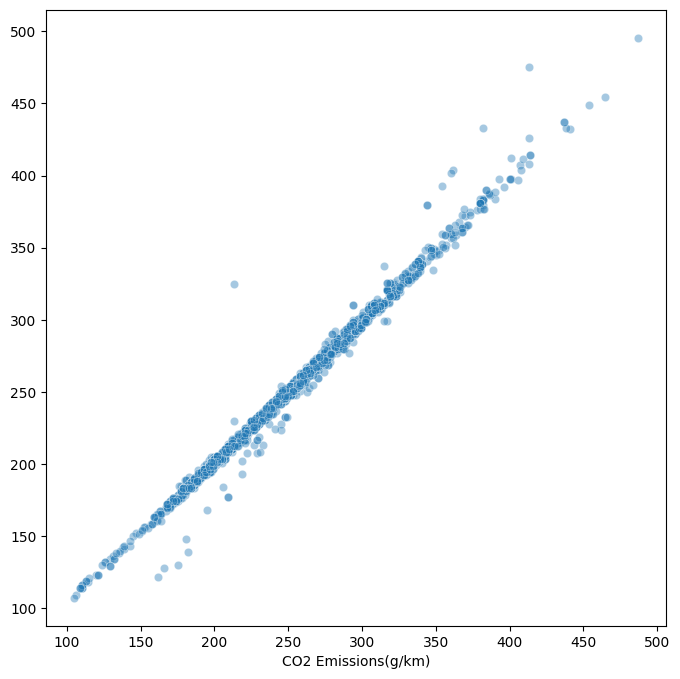

In [44]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)

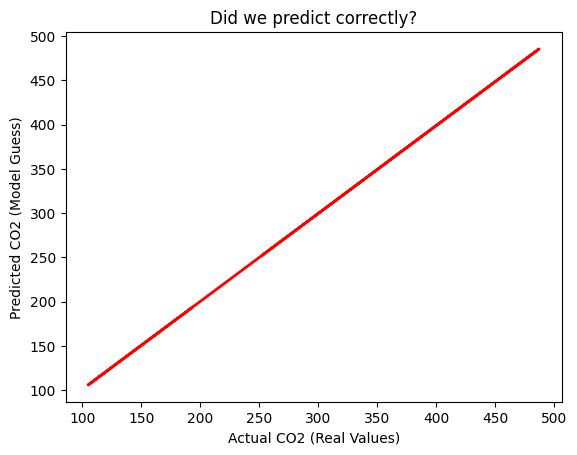

In [46]:
m, b = np.polyfit(y_test, y_pred, 1)
plt.plot(y_test, m*y_test + b, color='red', linewidth=2)
plt.xlabel("Actual CO2 (Real Values)")
plt.ylabel("Predicted CO2 (Model Guess)")
plt.title("Did we predict correctly?")
plt.show()


# 🚀 Executive Summary & Recommendations

### 1. Model Performance
We successfully built a Linear Regression model to predict CO2 emissions.
*   **Accuracy (R2 Score):** 0.9883 (The model explains 98.8% of the variance).
*   **Error Rate (RMSE):** 6.34 g/km (On average, predictions are within ~6g of the truth).
*   **Conclusion:** This model is highly reliable for deployment.

### 2. Key Drivers of Emissions
Based on our analysis of the data and model coefficients:
1.  **Fuel Consumption (Highest Impact):** This is the #1 predictor. For every 1 L/100km increase in fuel consumption, CO2 emissions rise by approx **22.3 grams**.
2.  **Fuel Type Matters:**
    *   **Ethanol (E85)** is the cleanest fuel in this dataset, reducing emissions by ~143g compared to Diesel.
    *   **Regular Gasoline (X)** shows high variability, meaning engine efficiency plays a larger role here.
3.  **Engine Size:** While correlated, its direct impact is captured mostly through fuel consumption.

### 3. Business Recommendations
To meet emission reduction targets, the Global Automotive Council should:
*   **Prioritize Fuel Efficiency:** Since fuel consumption has the strongest correlation (0.92) and highest model weight, R&D should focus on MPG improvements rather than just reducing engine size.
*   **Incentivize Ethanol Adoption:** Vehicles using Fuel Type E showed significantly lower median emissions in our boxplot analysis.
*   **Monitor "Type X" Vehicles:** Regular gasoline cars have the widest range of emissions (tallest boxplot). Stricter regulations are needed specifically for this segment to cap the "outliers" we identified.
